In [1]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from dataclasses import dataclass
from collections import Counter
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter, medfilt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") 

@dataclass
class RawFileData:
    path: str 
    file_id: str
    class_name: str
    region: str
    center: str
    waves: np.ndarray
    intensities: np.ndarray

cache_files = list(Path("/kaggle/input").rglob("*.joblib")) + list(Path("/kaggle/working").rglob("*.joblib"))
if not cache_files:
    raise FileNotFoundError("Cache file .joblib not found.")
CACHE_PATH = str(cache_files[0])

OUTPUT_DIR = Path("/kaggle/working/output_final_presentation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CLASS_DIR_TO_LABEL = {"control": "control", "endo": "endo_hsp70", "exo": "exo_hsp70"}

raw_data = joblib.load(CACHE_PATH)
print(f"Loaded {len(raw_data)} files from cache.")

def preprocess_spectra_advanced(matrix: np.ndarray, center: str) -> tuple[np.ndarray, np.ndarray]:
    """Смерть шуму: Медиана + Савицкий-Голей (без производной) + SNV"""
    mean_intensities = np.mean(matrix, axis=1)
    threshold = np.percentile(mean_intensities, 5) 
    valid_mask = mean_intensities > threshold
    filtered = matrix[valid_mask]

    despiked = medfilt(filtered, kernel_size=(1, 3))

    smoothed = savgol_filter(despiked, window_length=15, polyorder=3, deriv=0, axis=1)
    mean = smoothed.mean(axis=1, keepdims=True)
    std = smoothed.std(axis=1, keepdims=True)
    std[std < 1e-8] = 1.0 
    processed = (smoothed - mean) / std
    
    return processed, valid_mask

Loaded 237 files from cache.


Loading data for spectral visualization...


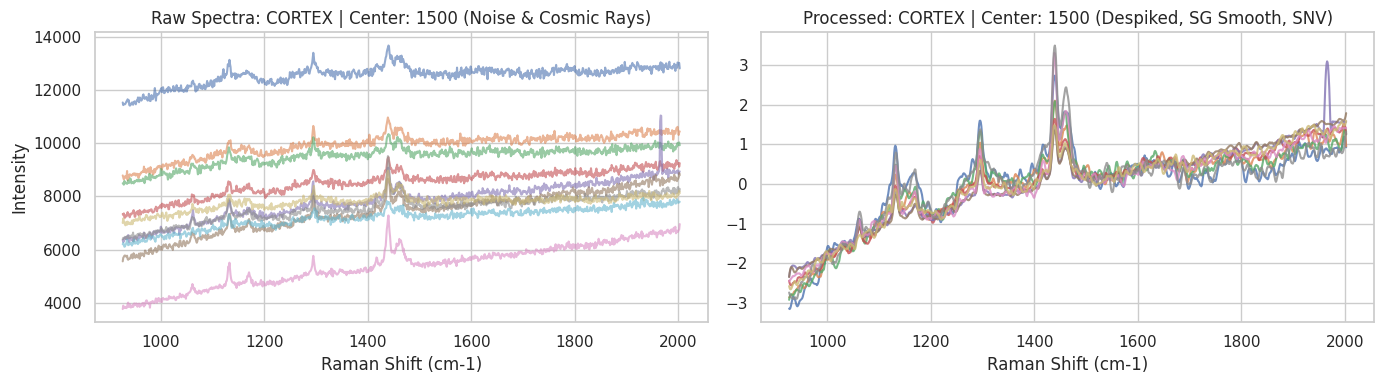

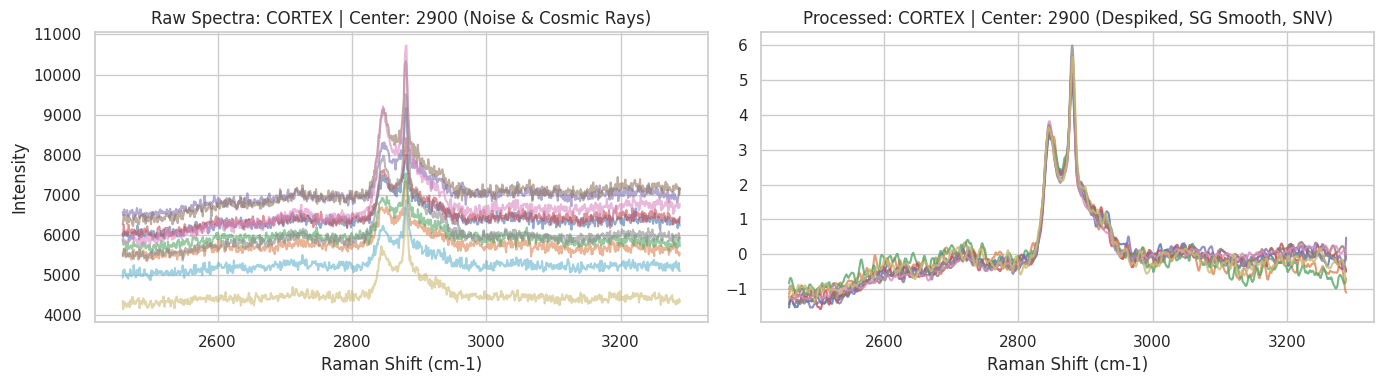

In [2]:
print("Loading data for spectral visualization...")

sample_1500 = next((f for f in raw_data if f.center == "1500"), None)
sample_2900 = next((f for f in raw_data if f.center == "2900"), None)

def plot_spectra_comparison(sample, title):
    if sample is None: return
    raw_intensities = sample.intensities[:10] 
    common_axis = np.linspace(sample.waves.min(), sample.waves.max(), 1024)

    f = interp1d(sample.waves, raw_intensities, axis=1)
    raw_aligned = f(common_axis)
    
    processed_intensities, _ = preprocess_spectra_advanced(raw_aligned, sample.center)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    for i in range(len(raw_aligned)):
        ax1.plot(common_axis, raw_aligned[i], alpha=0.6)
    ax1.set_title(f"Raw Spectra: {title} (Noise & Cosmic Rays)")
    ax1.set_xlabel("Raman Shift (cm-1)")
    ax1.set_ylabel("Intensity")
    
    for i in range(len(processed_intensities)):
        ax2.plot(common_axis, processed_intensities[i], alpha=0.8)
    ax2.set_title(f"Processed: {title} (Despiked, SG Smooth, SNV)")
    ax2.set_xlabel("Raman Shift (cm-1)")
    
    plt.tight_layout()
    plt.show()

if sample_1500:
    plot_spectra_comparison(sample_1500, f"{sample_1500.region.upper()} | Center: 1500")
if sample_2900:
    plot_spectra_comparison(sample_2900, f"{sample_2900.region.upper()} | Center: 2900")

In [3]:
print("Initializing Grandmaster Ensemble Training...")
subtasks = {}
for fd in raw_data:
    key = f"{fd.region.upper()} | Center: {fd.center}"
    if key not in subtasks: subtasks[key] = []
    subtasks[key].append(fd)

label_enc = LabelEncoder().fit(list(CLASS_DIR_TO_LABEL.values()))
class_names = list(label_enc.classes_)

task_results = {}

for task_name, subset in subtasks.items():
    if len(subset) < 5: continue
    current_center = subset[0].center 
    print(f"\nProcessing Task: {task_name} | Files: {len(subset)}")

    min_w = np.max([f.waves.min() for f in subset])
    max_w = np.min([f.waves.max() for f in subset])
    common_axis = np.linspace(min_w, max_w, 1024) 
    
    X_list, y_list, file_id_list = [], [], []
    for fd in subset:
        f = interp1d(fd.waves, fd.intensities, axis=1, fill_value="extrapolate")
        aligned = f(common_axis)
        n_pixels = aligned.shape[0]
        X_list.append(aligned)
        y_list.append(np.full(n_pixels, label_enc.transform([fd.class_name])[0]))
        file_id_list.append(np.full(n_pixels, fd.file_id))

    X_raw = np.vstack(X_list)
    y_raw = np.concatenate(y_list)
    file_ids_raw = np.concatenate(file_id_list)

    X_proc, valid_mask = preprocess_spectra_advanced(X_raw, current_center)
    y = y_raw[valid_mask]
    file_ids = file_ids_raw[valid_mask]

    splitter = GroupKFold(n_splits=min(5, len(subset)))
    pixel_probas = np.zeros((len(y), 3))
    
    xgb_params = {
        'objective': 'multi:softprob', 
        'num_class': 3,
        'learning_rate': 0.05,
        'max_depth': 5, 
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_lambda': 5.0, 
        'tree_method': 'hist',
        'device': 'cuda',
        'seed': 42,
        'verbosity': 0
    }

    rf_model = RandomForestClassifier(n_estimators=300, max_depth=12, max_features='sqrt', class_weight='balanced', n_jobs=-1, random_state=42)
    
    fold_loss_history = []
    global_importances = np.zeros(X_proc.shape[1]) 

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(X_proc, y, groups=file_ids), 1):
        X_train_fold = X_proc[train_idx]
        X_valid_fold = X_proc[valid_idx]
        
        sample_weights = compute_sample_weight(class_weight='balanced', y=y[train_idx])
        
        dtrain = xgb.DMatrix(X_train_fold, label=y[train_idx], weight=sample_weights)
        dvalid = xgb.DMatrix(X_valid_fold, label=y[valid_idx])
        
        evals_result = {}
        xgb_bst = xgb.train(
            xgb_params, dtrain, num_boost_round=150, 
            evals=[(dtrain, 'Train'), (dvalid, 'Validation')],
            evals_result=evals_result, verbose_eval=False
        )
        xgb_probs = xgb_bst.predict(dvalid)
        
        if fold == 1: 
            fold_loss_history = evals_result

        rf_model.fit(X_train_fold, y[train_idx])
        rf_probs = rf_model.predict_proba(X_valid_fold)

        global_importances += rf_model.feature_importances_ / splitter.get_n_splits()
        
        pixel_probas[valid_idx] = (xgb_probs + rf_probs) / 2.0

    file_true, file_pred = [], []
    for f_id in np.unique(file_ids):
        mask = (file_ids == f_id)
        true_label = y[mask][0]
        mean_probas = np.mean(pixel_probas[mask], axis=0)
        file_true.append(true_label)
        file_pred.append(np.argmax(mean_probas))

    acc = accuracy_score(file_true, file_pred)
    task_results[task_name] = {
        'true': file_true,
        'pred': file_pred,
        'acc': acc,
        'loss_history': fold_loss_history,
        'common_axis': common_axis,        
        'importances': global_importances  
    }
    print(f"Completed {task_name}. Accuracy: {acc*100:.2f}%")

Initializing Grandmaster Ensemble Training...

Processing Task: CORTEX | Center: 1500 | Files: 54
Completed CORTEX | Center: 1500. Accuracy: 79.63%

Processing Task: CORTEX | Center: 2900 | Files: 55
Completed CORTEX | Center: 2900. Accuracy: 27.27%

Processing Task: STRIATUM | Center: 1500 | Files: 36
Completed STRIATUM | Center: 1500. Accuracy: 75.00%

Processing Task: STRIATUM | Center: 2900 | Files: 36
Completed STRIATUM | Center: 2900. Accuracy: 63.89%

Processing Task: CEREBELLUM | Center: 1500 | Files: 28
Completed CEREBELLUM | Center: 1500. Accuracy: 92.86%

Processing Task: CEREBELLUM | Center: 2900 | Files: 28
Completed CEREBELLUM | Center: 2900. Accuracy: 71.43%



FINAL EVALUATION DASHBOARDS (Confusion Matrix & Loss)

[CORTEX | Center: 1500] Accuracy: 79.63%
              precision    recall  f1-score   support

     control     0.7895    0.8333    0.8108        18
  endo_hsp70     0.7857    0.6111    0.6875        18
   exo_hsp70     0.8095    0.9444    0.8718        18

    accuracy                         0.7963        54
   macro avg     0.7949    0.7963    0.7900        54
weighted avg     0.7949    0.7963    0.7900        54



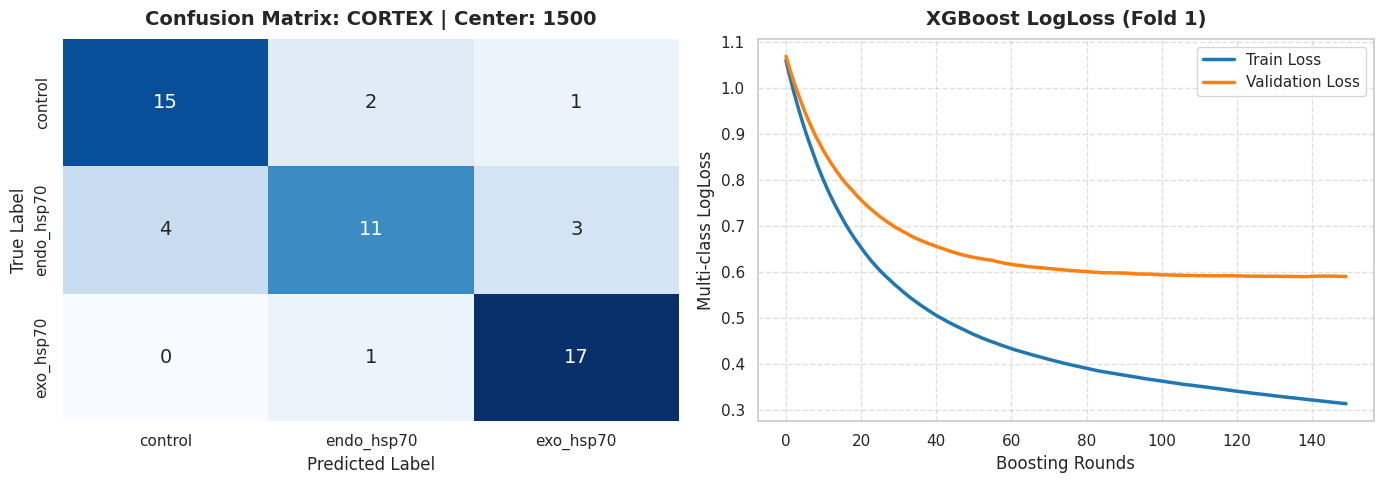


[CORTEX | Center: 2900] Accuracy: 27.27%
              precision    recall  f1-score   support

     control     0.2000    0.1667    0.1818        18
  endo_hsp70     0.0000    0.0000    0.0000        19
   exo_hsp70     0.3000    0.6667    0.4138        18

    accuracy                         0.2727        55
   macro avg     0.1667    0.2778    0.1985        55
weighted avg     0.1636    0.2727    0.1949        55



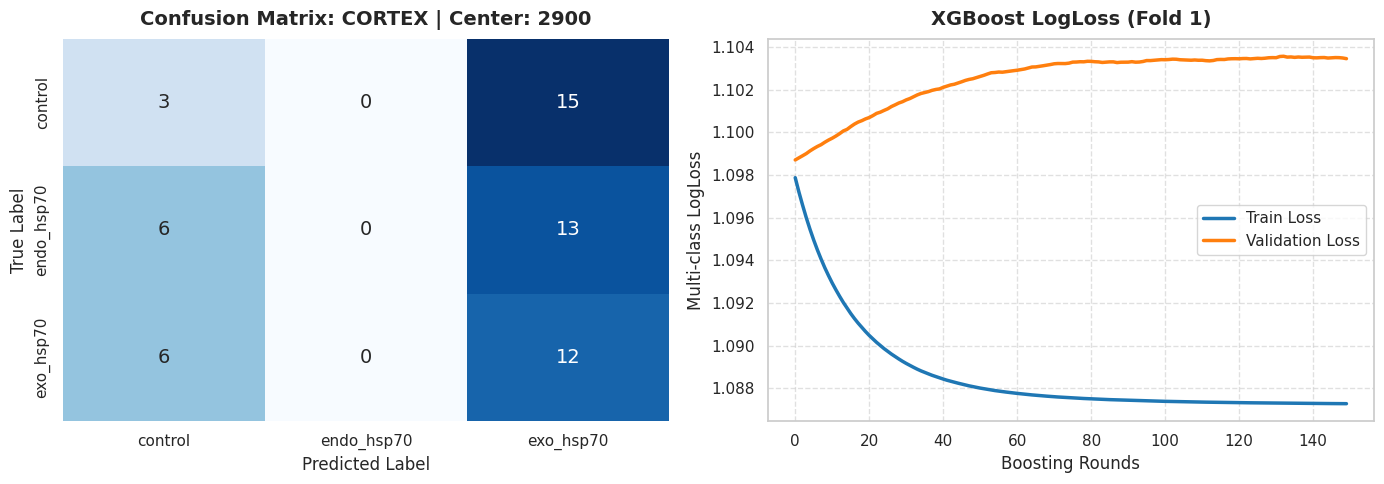


[STRIATUM | Center: 1500] Accuracy: 75.00%
              precision    recall  f1-score   support

     control     0.6667    0.6667    0.6667        12
  endo_hsp70     1.0000    0.7500    0.8571        12
   exo_hsp70     0.6667    0.8333    0.7407        12

    accuracy                         0.7500        36
   macro avg     0.7778    0.7500    0.7549        36
weighted avg     0.7778    0.7500    0.7549        36



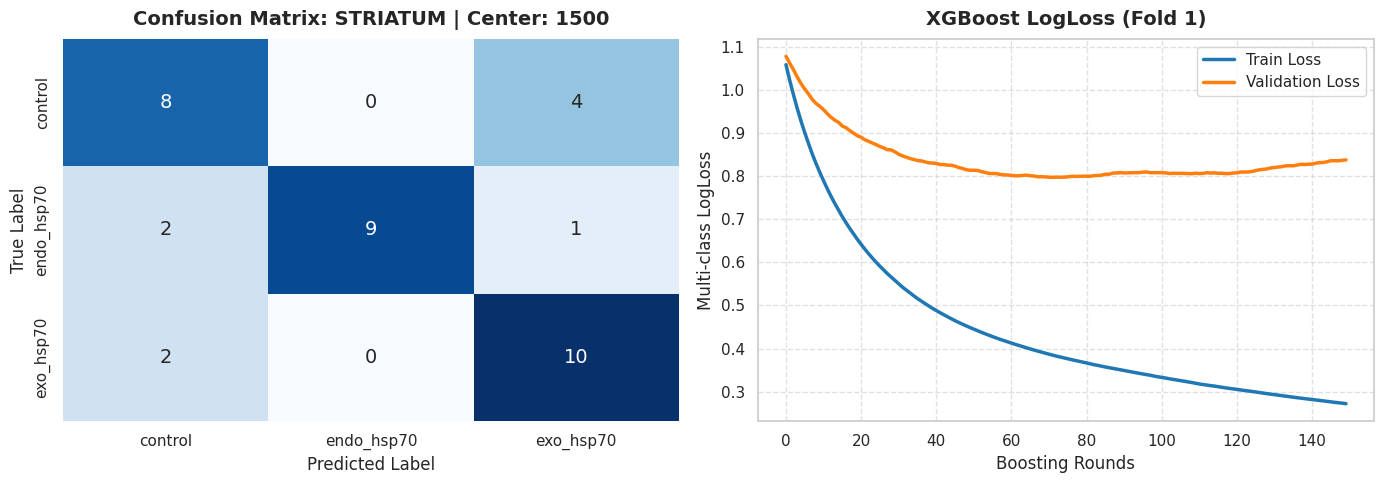


[STRIATUM | Center: 2900] Accuracy: 63.89%
              precision    recall  f1-score   support

     control     0.5000    0.4167    0.4545        12
  endo_hsp70     1.0000    0.8333    0.9091        12
   exo_hsp70     0.5000    0.6667    0.5714        12

    accuracy                         0.6389        36
   macro avg     0.6667    0.6389    0.6450        36
weighted avg     0.6667    0.6389    0.6450        36



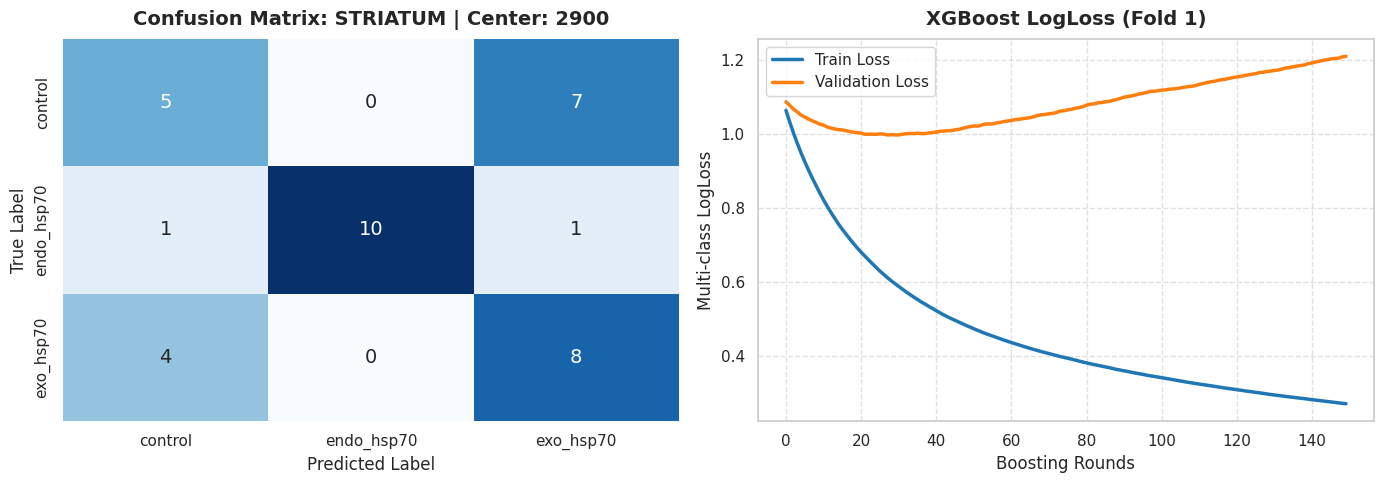


[CEREBELLUM | Center: 1500] Accuracy: 92.86%
              precision    recall  f1-score   support

     control     0.9091    1.0000    0.9524        10
  endo_hsp70     1.0000    0.8333    0.9091         6
   exo_hsp70     0.9167    0.9167    0.9167        12

    accuracy                         0.9286        28
   macro avg     0.9419    0.9167    0.9260        28
weighted avg     0.9318    0.9286    0.9278        28



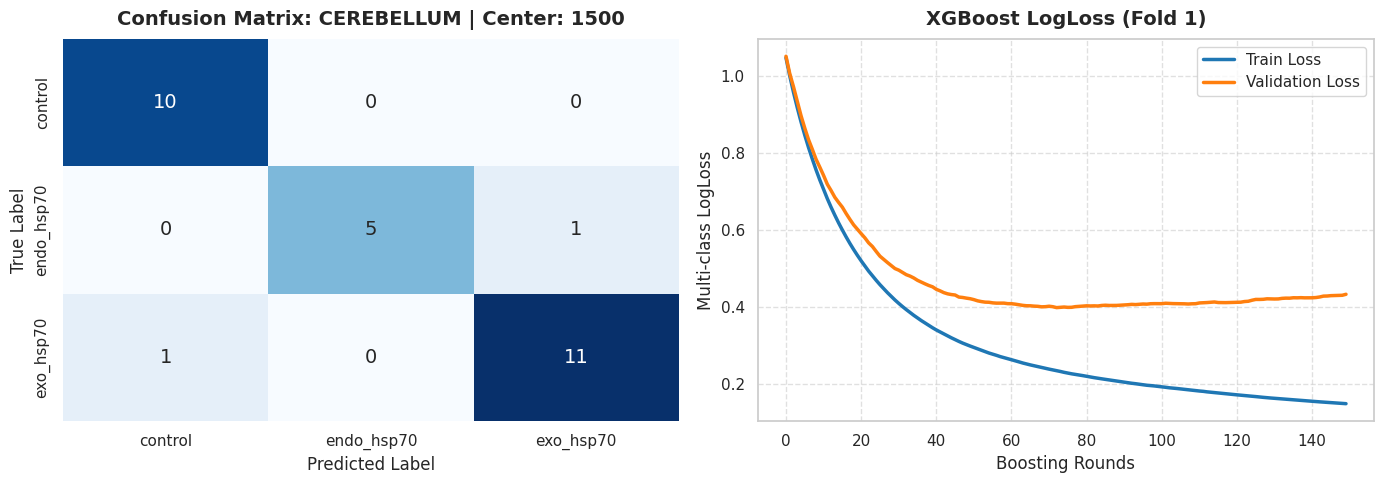


[CEREBELLUM | Center: 2900] Accuracy: 71.43%
              precision    recall  f1-score   support

     control     0.8182    0.9000    0.8571        10
  endo_hsp70     0.5714    0.6667    0.6154         6
   exo_hsp70     0.7000    0.5833    0.6364        12

    accuracy                         0.7143        28
   macro avg     0.6965    0.7167    0.7030        28
weighted avg     0.7147    0.7143    0.7107        28



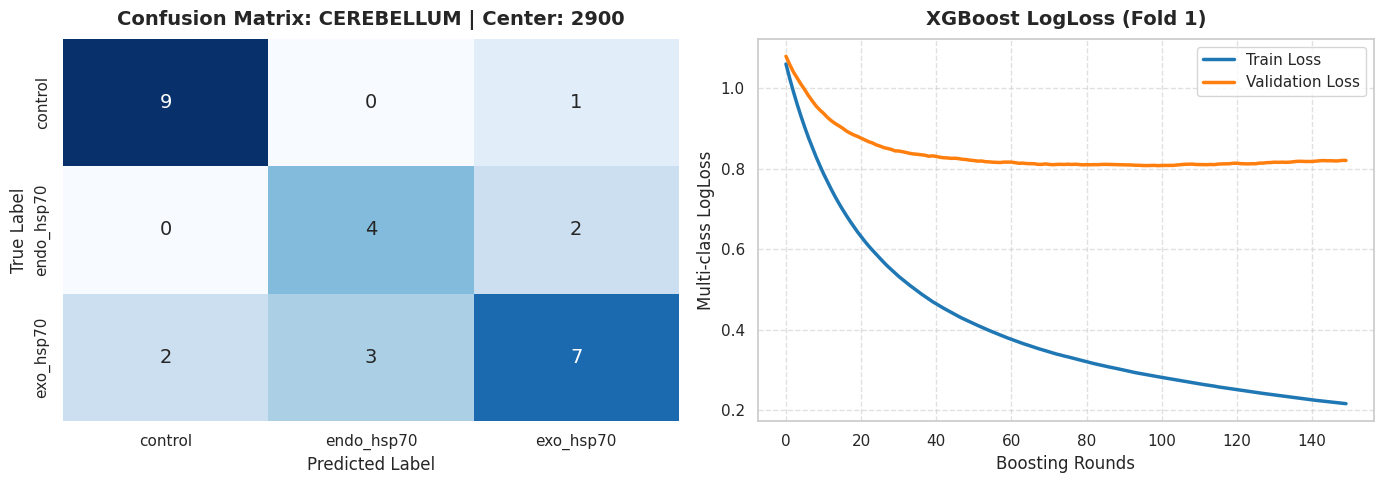


FINAL ACCURACY SCOREBOARD
-> CEREBELLUM | Center: 1500: 92.86%
-> CORTEX | Center: 1500: 79.63%
-> STRIATUM | Center: 1500: 75.00%
-> CEREBELLUM | Center: 2900: 71.43%
-> STRIATUM | Center: 2900: 63.89%
-> CORTEX | Center: 2900: 27.27%


In [4]:
print("\n" + "="*50)
print("FINAL EVALUATION DASHBOARDS (Confusion Matrix & Loss)")
print("="*50)

final_scores = {}

for task_name, data in task_results.items():
    acc = data['acc']
    final_scores[task_name] = acc
    
    print(f"\n[{task_name}] Accuracy: {acc*100:.2f}%")
    print(classification_report(data['true'], data['pred'], target_names=class_names, digits=4, zero_division=0))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(data['true'], data['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
                xticklabels=class_names, yticklabels=class_names, cbar=False,
                annot_kws={"size": 14}) 
    ax1.set_title(f"Confusion Matrix: {task_name}", fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel("True Label", fontsize=12)
    ax1.set_xlabel("Predicted Label", fontsize=12)

    history = data['loss_history']
    if history:
        epochs = len(history['Train']['mlogloss'])
        x_axis = range(0, epochs)
        ax2.plot(x_axis, history['Train']['mlogloss'], label='Train Loss', color='#1f77b4', linewidth=2.5)
        ax2.plot(x_axis, history['Validation']['mlogloss'], label='Validation Loss', color='#ff7f0e', linewidth=2.5)
        ax2.set_title("XGBoost LogLoss (Fold 1)", fontsize=14, fontweight='bold', pad=10)
        ax2.set_xlabel("Boosting Rounds", fontsize=12)
        ax2.set_ylabel("Multi-class LogLoss", fontsize=12)
        ax2.legend(fontsize=11)
        ax2.grid(True, linestyle='--', alpha=0.6)
    else:
        ax2.text(0.5, 0.5, 'Loss history not available', ha='center', va='center')

    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("FINAL ACCURACY SCOREBOARD")
print("="*50)
for task, acc in sorted(final_scores.items(), key=lambda item: item[1], reverse=True):
    print(f"-> {task}: {acc*100:.2f}%")
print("="*50)


EXTRA TASK: RAMAN BIOMARKER DISCOVERY (Feature Importances)


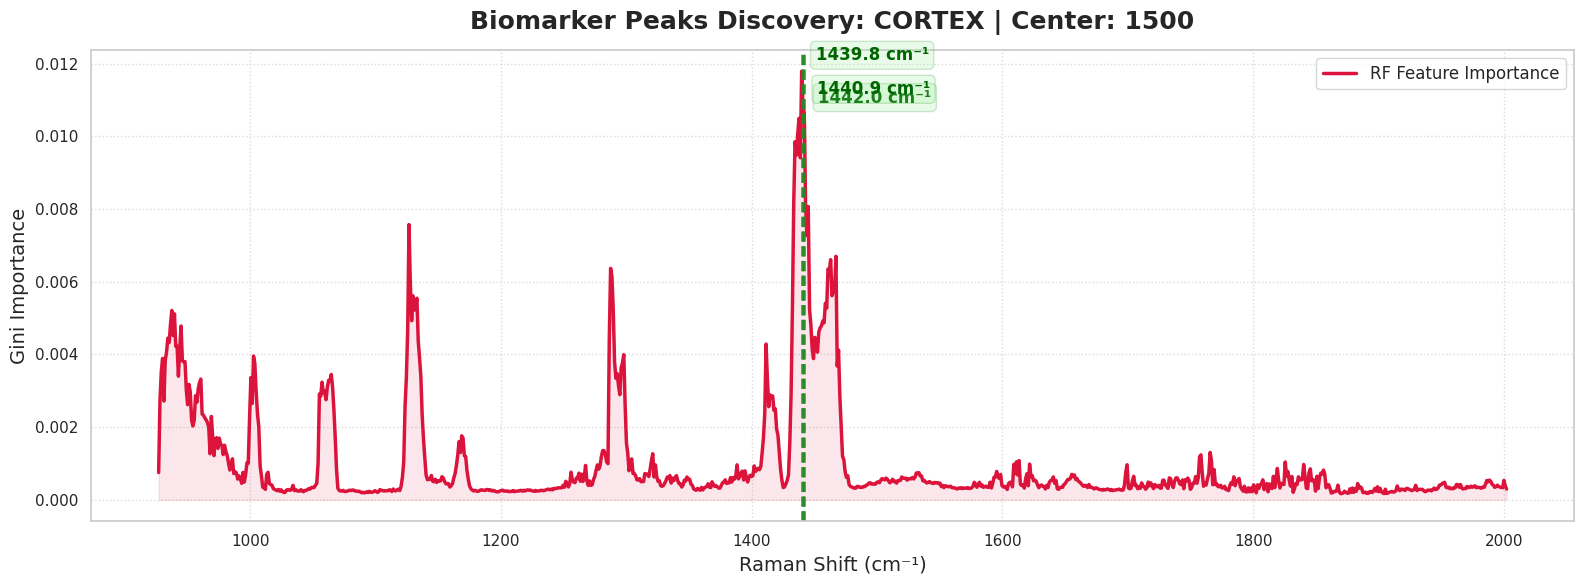

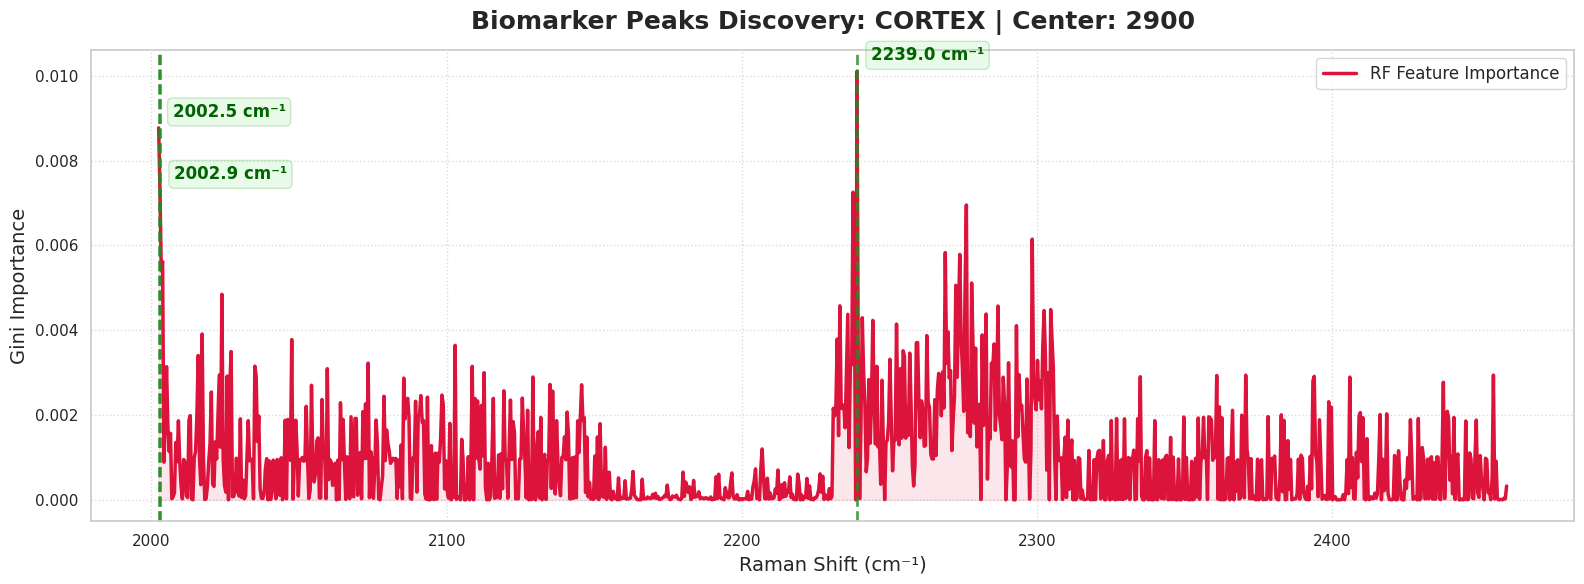

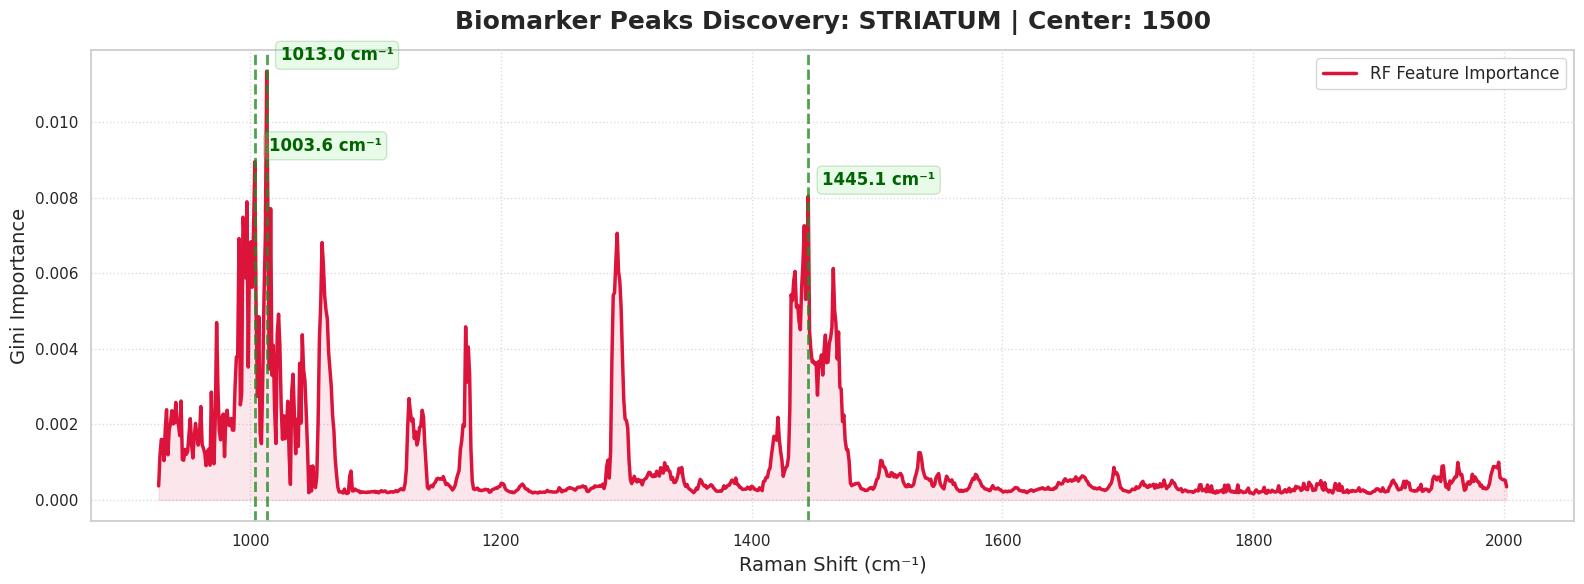

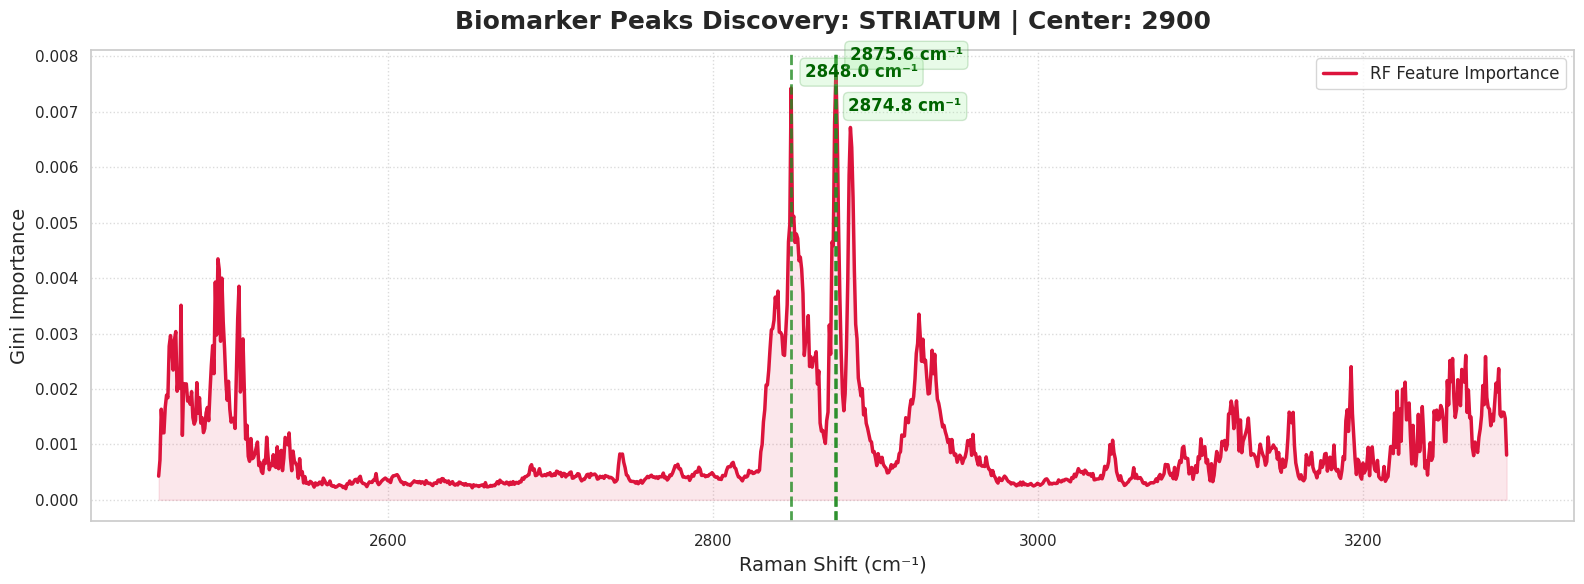

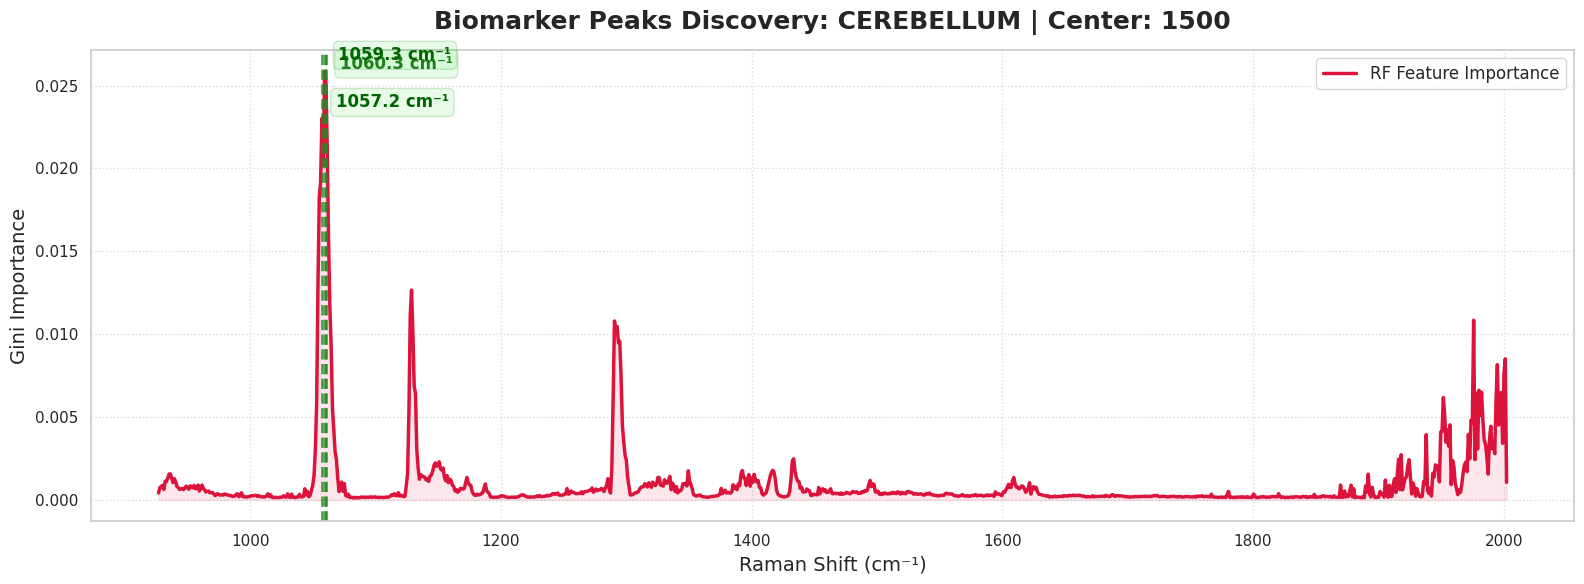

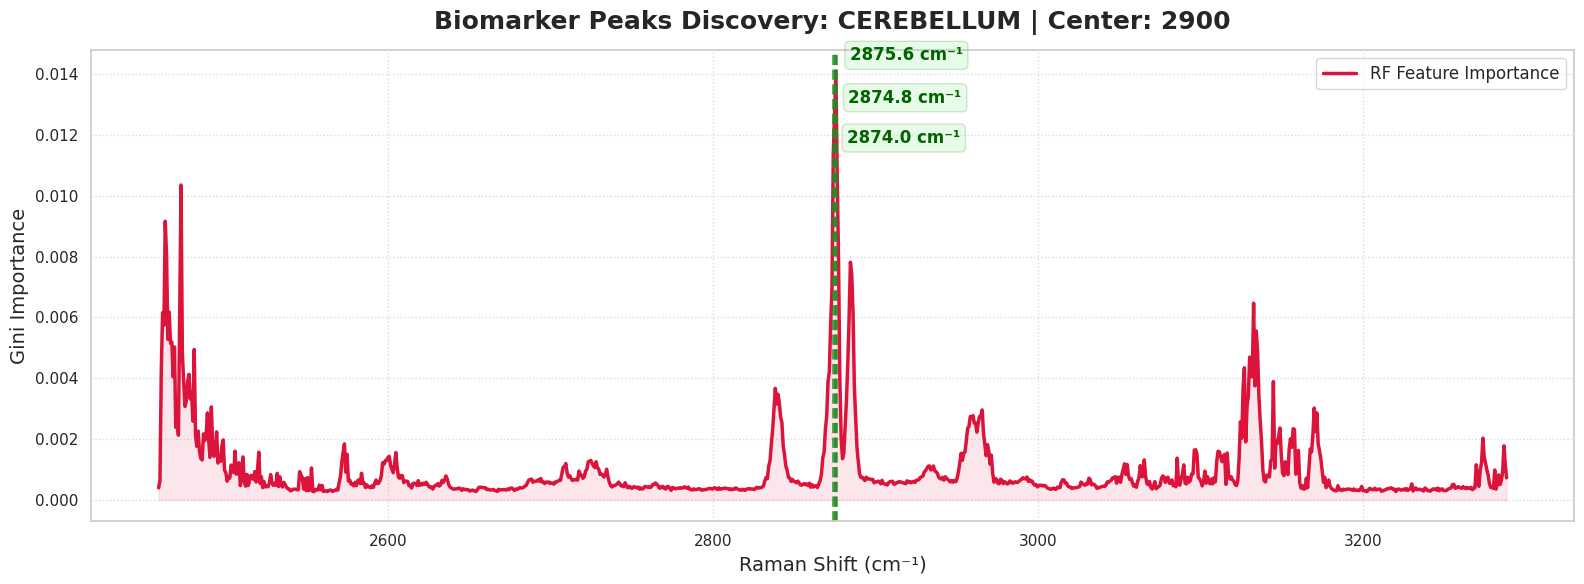

In [5]:
print("\n" + "="*50)
print("EXTRA TASK: RAMAN BIOMARKER DISCOVERY (Feature Importances)")
print("="*50)

for task_name, data in task_results.items():
    plt.figure(figsize=(16, 6)) 
    
    common_axis = data['common_axis']
    importances = data['importances']

    plt.plot(common_axis, importances, color='crimson', linewidth=2.5, label='RF Feature Importance')
    
    plt.fill_between(common_axis, importances, color='crimson', alpha=0.1)
    
    plt.title(f"Biomarker Peaks Discovery: {task_name}", fontsize=18, fontweight='bold', pad=15)
    plt.xlabel("Raman Shift (cm⁻¹)", fontsize=14)
    plt.ylabel("Gini Importance", fontsize=14)
    
    top_3_idx = np.argsort(importances)[-3:]
    
    for i, idx in enumerate(top_3_idx):
        peak_wave = common_axis[idx]
        peak_imp = importances[idx]
 
        plt.axvline(x=peak_wave, color='forestgreen', linestyle='--', alpha=0.8, linewidth=2)

        plt.annotate(f"{peak_wave:.1f} cm⁻¹", 
                     xy=(peak_wave, peak_imp),
                     xytext=(10, 5), 
                     textcoords="offset points",
                     ha='left', va='bottom',
                     fontsize=12, fontweight='bold', color='darkgreen',
                     bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.2, ec="forestgreen"))

    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()

# **ДЛЯ ЖЮРИ**

In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import xgboost as xgb

def predict_jury_sample(file_path, region_task, center_val, xgb_model, rf_model, label_encoder, task_dict):
    df = pd.read_csv(file_path, sep='\t')
    
    waves = np.array([float(col) for col in df.columns])
    raw_intensities = df.values
    
    common_axis = task_dict[region_task]['common_axis']
    
    f = interp1d(waves, raw_intensities, axis=1, fill_value="extrapolate")
    aligned = f(common_axis)
    
    X_proc, valid_mask = preprocess_spectra_advanced(aligned, center_val)
    
    dtest = xgb.DMatrix(X_proc)
    xgb_probs = xgb_model.predict(dtest)
    
    rf_probs_raw = rf_model.predict_proba(X_proc)
    rf_probs = np.zeros((len(X_proc), 3))
    for idx, cls in enumerate(rf_model.classes_):
        rf_probs[:, cls] = rf_probs_raw[:, idx]
        
    pixel_probas = (xgb_probs + rf_probs) / 2.0
    mean_probas = np.mean(pixel_probas, axis=0)
    
    final_idx = np.argmax(mean_probas)
    final_class = label_encoder.inverse_transform([final_idx])[0]
    
    print(f"\n" + "="*40)
    print(f"JURY INFERENCE RESULT")
    print(f"="*40)
    print(f"File: {file_path}")
    print(f"Task: {region_task}")
    print(f"Final Prediction \t=> {final_class.upper()}")
    print(f"Soft Probabilities \t=> {dict(zip(label_encoder.classes_, np.round(mean_probas, 4)))}")
    print("="*40 + "\n")
    
    return final_class